## 06 Formal Error Propagation

Applys the standard uncertainty propagation formula to report predictions with real confidence intervals.

-> Formula:
$$\sigma_f = \sqrt{\sum_i \left(\frac{\partial f}{\partial x_i}\right)^2 \sigma_{x_i}^2}$$


In [9]:
import os
import sqlite3
import sys
import warnings
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
sys.path.insert(0, ROOT)
os.chdir(os.path.join(ROOT, 'notebooks'))

from src.uncertainty import calibrate_dataframe_probabilities, score_dataframe_with_uncertainty, uncertainty_report  
from src.visualization import PALETTE, plot_prediction_uncertainty, set_style  

set_style()

try:
    LIFELINES_OK = True
except Exception:
    LIFELINES_OK = False

DATA_DIR = os.path.join(ROOT, 'data')
df_clean = pd.read_csv(os.path.join(DATA_DIR, 'telco_clean.csv'))
df_features = pd.read_csv(os.path.join(DATA_DIR, 'telco_features.csv'))
df_final = pd.read_csv(os.path.join(DATA_DIR, 'telco_final.csv'))
df = df_features.copy()
df_model = pd.get_dummies(df, columns=['Contract','PaymentMethod','InternetService'], drop_first=True)

conn = sqlite3.connect(':memory:')
df.to_sql('telco', conn, if_exists='replace', index=False)
df_clean.to_sql('telco_clean', conn, if_exists='replace', index=False)

print(f'Ready: {len(df):,} customers | churn rate {df.Churn_bin.mean():.1%}')

Ready: 7,043 customers | churn rate 26.5%


In [10]:
# Calculate uncertainty for the entire dataset
print('Computing error propagation...')
df = score_dataframe_with_uncertainty(df, t_horizon=6.0)
print('Complete.')
df[['E0','sigma_E0','gamma','sigma_gamma','prob_churn','sigma_prob','prob_inf','prob_sup','risk_level']].head(10)

Computing error propagation...
Complete.


,E0,sigma_E0,gamma,sigma_gamma,prob_churn,sigma_prob,prob_inf,prob_sup,risk_level
0,0.294915,0.017038,0.1658,0.02,0.516223,0.023958,0.492265,0.540181,HIGH
1,0.795795,0.000213,0.2258,0.02,0.052685,0.023140,0.029544,0.075825,LOW
2,0.342084,0.022113,0.2058,0.02,0.324766,0.027620,0.297146,0.352386,UNCERTAIN
3,0.801175,0.000351,0.2658,0.02,0.040351,0.024397,0.015954,0.064748,LOW
4,0.322107,0.022113,0.1258,0.02,0.684732,0.019008,0.665724,0.703740,HIGH
5,0.554780,0.015012,0.1458,0.02,0.550158,0.020645,0.529513,0.570803,HIGH
6,0.753903,0.001700,0.1858,0.02,0.385476,0.021758,0.363718,0.407233,HIGH
7,0.621795,0.012151,0.1858,0.02,0.294535,0.021127,0.273408,0.315662,MEDIUM
8,0.774679,0.000839,0.1658,0.02,0.435984,0.024033,0.411951,0.460017,HIGH
9,0.800080,0.000003,0.2458,0.02,0.045747,0.023778,0.021969,0.069524,LOW


### Calibrating the raw probability

Bug found in review: the raw physics-based prob_churn = 1 - E(t=6m) is systematically overconfident on this dataset - its mean is roughly double the actual churn rate, which pushed the vast majority of customers into risk_level='HIGH' (see the uncalibrated report below vs the calibrated one). Isotonic regression corrects the average level while preserving the raw model's rank ordering (it's fit in-sample, consistent with how E0/E_eq/gamma were already hand-calibrated on the whole population - see physics.estimate_params_discussion)

In [11]:
print('Uncalibrated report (for comparison):')
uncertainty_report(df.assign(prob_churn_calibrated=df['prob_churn']))

Uncalibrated report (for comparison):


,total,mean_prob,mean_sigma,churn_rate
risk_level,,,,
HIGH,2398,0.5012,0.0226,0.5563
UNCERTAIN,455,0.2953,0.0379,0.2330
MEDIUM,1514,0.2733,0.0219,0.2001
LOW,2676,0.0473,0.0263,0.0471


In [12]:
df, prob_calibrator = calibrate_dataframe_probabilities(df)
print(f"Mean raw prob_churn: {df['prob_churn'].mean():.3f}")
print(f"Mean calibrated prob_churn: {df['prob_churn_calibrated'].mean():.3f}")
print(f"Actual churn rate: {df['Churn_bin'].mean():.3f}")

Mean raw prob_churn: 0.266
Mean calibrated prob_churn: 0.265
Actual churn rate: 0.265


In [13]:
print('Uncertainty Report by Risk Level')
uncertainty_report(df)

Uncertainty Report by Risk Level


,total,mean_prob,mean_sigma,churn_rate
risk_level,,,,
HIGH,1967,0.6041,0.0227,0.6019
MEDIUM,1129,0.2876,0.0217,0.2764
UNCERTAIN,371,0.2707,0.0405,0.2911
LOW,3576,0.0715,0.0254,0.0741


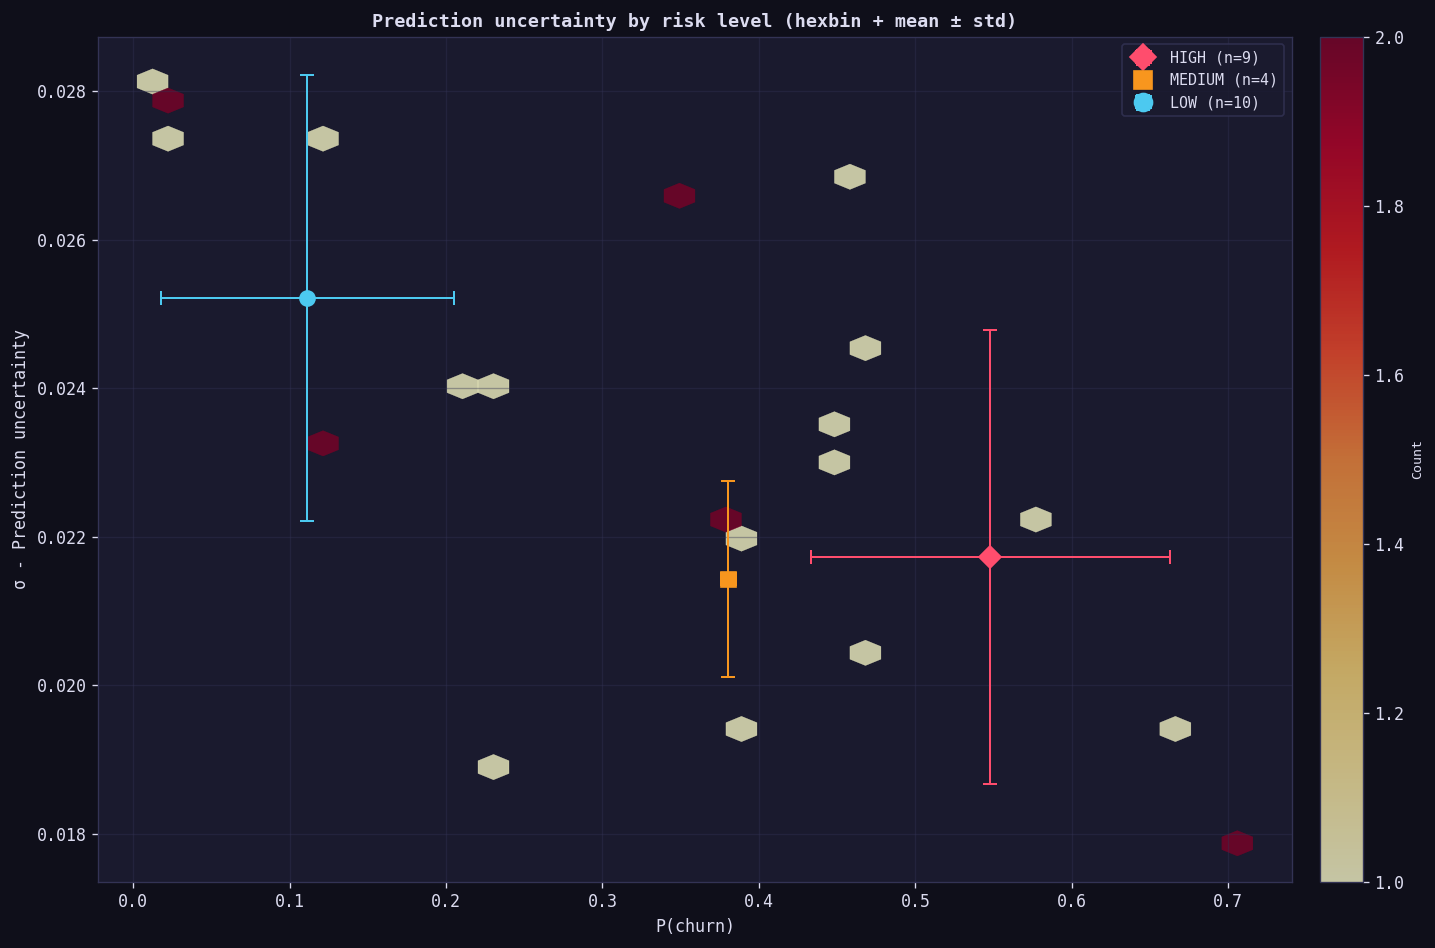

In [14]:
# Visualization: sample of 25 customers with error bars
sample = df.sample(25, random_state=42)
fig, ax = plt.subplots(figsize=(13,8))
plot_prediction_uncertainty(sample, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '06_uncertainty_prediction.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

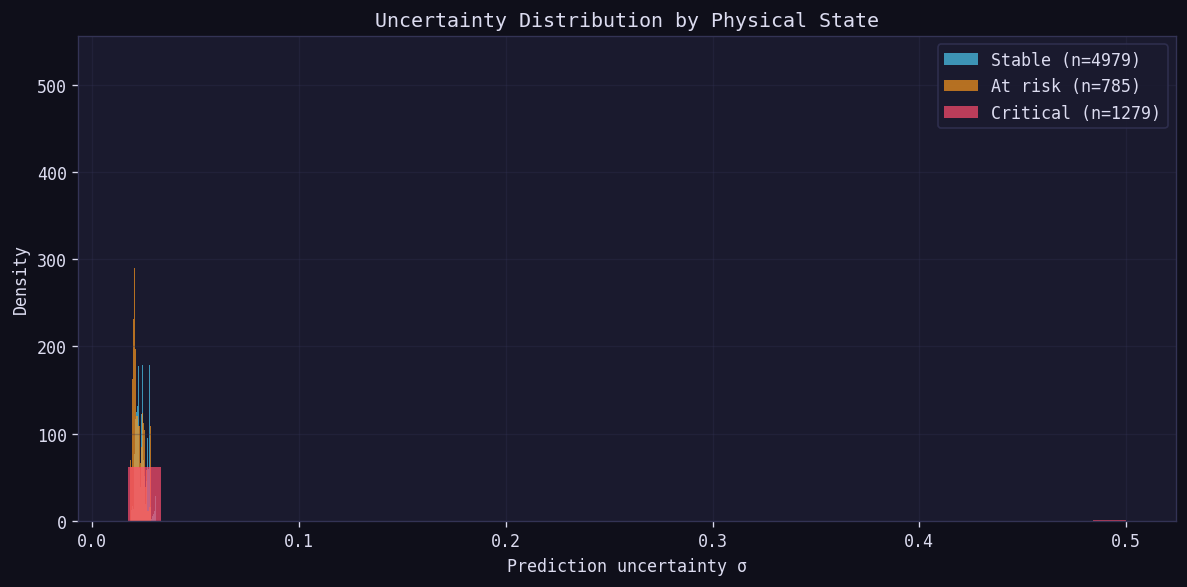

In [15]:
# Uncertainty distribution by physical state
fig, ax = plt.subplots(figsize=(10,5))
for state, color in [('Stable', PALETTE['no_churn']), ('At risk', PALETTE['accent']), ('Critical', PALETTE['churn'])]:
    subset = df[df['physical_state']==state]['sigma_prob']
    if len(subset) > 0:
        ax.hist(subset, bins=30, alpha=0.7, color=color, label=f'{state} (n={len(subset)})', edgecolor='none', density=True)
ax.set_xlabel('Prediction uncertainty σ')
ax.set_ylabel('Density')
ax.set_title('Uncertainty Distribution by Physical State')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '06_sigma_distribution.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [16]:
df.to_csv(os.path.join(DATA_DIR, 'telco_final.csv'), index=False)
print('Final dataset saved to data/telco_final.csv')

Final dataset saved to data/telco_final.csv


### Why does uncertainty matter for the business?

| Risk level | Meaning | Recommended action |
|---|---|---|
| HIGH (low σ) | Certain to churn | Intervene urgently with active retention |
| UNCERTAIN (high σ) | Insufficient information | Collect more data before acting | |
| MEDIUM | Moderate probability | Preventive engagement campaign |
| LOW (low σ) | Certain to stay | Minimal monitoring |

A model without uncertainty mixes the HIGH group with the UNCERTAIN group, wasting resources on customers for which there is no real certainty.
